# 第 15 章　注意力機制與 Transformer — 實作 Notebook

「醫學生的機器學習入門」第 15 章配套程式。建議在 **Google Colab** 執行（選單「執行階段 → 全部執行」，CPU 即可，不需要 GPU）；本機 Jupyter 也可以。

- 第 1–2 節：讀資料、用 TF-IDF + 邏輯迴歸做基準，只需要 Colab 預裝的 scikit-learn。
- 第 3–7 節：用 **Keras 3** 自己組一個迷你 Transformer 編碼器，並把注意力權重畫出來。**沒有安裝 Keras 的環境會自動跳過這幾節**，不會報錯。

資料集：Gretel `symptom_to_diagnosis`（Apache-2.0）。依資料集說明，它改編自 Kaggle 的 Symptom2Disease，並用大型語言模型把症狀改寫成「病人口吻」——**不是真實病人的病歷**，22 個診斷也是刻意均衡的教學設定，和真實門診的盛行率無關。結果僅供學習，不構成臨床建議。

## 0. 環境檢查
印出套件版本並固定隨機種子。Keras 必須在 `import` 之前設定 backend。

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"   # must be set before importing keras
import time
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import matplotlib.pyplot as plt

print("numpy", np.__version__, "| pandas", pd.__version__,
      "| scikit-learn", sklearn.__version__, "| matplotlib", matplotlib.__version__)
RS = 42

try:
    import keras
    from keras import layers, ops
    keras.utils.set_random_seed(RS)   # results may still differ slightly across versions/hardware
    HAS_KERAS = True
    print("keras", keras.__version__, "| backend:", keras.backend.backend())
except ImportError:
    keras = None
    HAS_KERAS = False
    print("Keras is not installed in this environment -> sections 3-7 will be skipped.")
    print("Run this notebook on Google Colab to try them, or `pip install tensorflow keras` locally.")

numpy 2.1.3 | pandas 2.2.3 | scikit-learn 1.6.1 | matplotlib 3.10.0


keras 3.13.2 | backend: tensorflow


## 1. 讀資料
直接從 Hugging Face 讀兩個 `.jsonl` 檔（訓練 853 筆、測試 212 筆），不需要安裝 `datasets` 套件。網路失敗時會印出清楚的錯誤訊息。

In [2]:
BASE = "https://huggingface.co/datasets/gretelai/symptom_to_diagnosis/resolve/main/"
try:
    train_df = pd.read_json(BASE + "train.jsonl", lines=True)
    test_df = pd.read_json(BASE + "test.jsonl", lines=True)
except Exception as e:
    raise RuntimeError(
        "Could not download the dataset from Hugging Face. Check your internet connection, "
        "or download train.jsonl / test.jsonl manually from " + BASE) from e

print("train:", train_df.shape, "| test:", test_df.shape)
print("number of diagnoses:", train_df["output_text"].nunique())
print(train_df["output_text"].value_counts().describe()[["min", "max"]])
for i in [0, 100, 400]:
    print(f"\n[{train_df.loc[i, 'output_text']}]", train_df.loc[i, "input_text"])

train: (853, 2) | test: (212, 2)
number of diagnoses: 22
min    32.0
max    40.0
Name: count, dtype: float64

[cervical spondylosis] I've been having a lot of pain in my neck and back. I've also been having trouble with my balance and coordination. I've been coughing a lot and my limbs feel weak.

[bronchial asthma] I've been coughing a lot, and it's hard to breathe. I've also been coughing up a lot of thick, mucusy saliva. I've been feeling really tired, and I have a fever.

[fungal infection] I have a rash all over my body, and it's really itchy. I have some bumps that are quite firm, and some areas that are a darker shade from the rest of my skin. It's really unpleasant.


22 個診斷每類大約 32–40 筆，刻意均衡。順便看一下句子有多長（以空白切開的字數）：

In [3]:
n_words = train_df["input_text"].str.split().str.len()
print(f"words per description: median {n_words.median():.0f}, max {n_words.max()}")

words per description: median 28, max 55


## 2. 基準模型：TF-IDF + 邏輯迴歸
第 5 章用過詞袋（bag-of-words）。TF-IDF 是它的加權版：在這句話出現越多次、在所有句子裡越少見的字，分數越高。`ngram_range=(1, 2)` 讓「chest pain」這種兩個字的片語也成為一欄，算是保留了一點點字序。

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

X_train_text, y_train_text = train_df["input_text"], train_df["output_text"]
X_test_text, y_test_text = test_df["input_text"], test_df["output_text"]

baseline = make_pipeline(TfidfVectorizer(ngram_range=(1, 2)),
                         LogisticRegression(max_iter=2000))
baseline.fit(X_train_text, y_train_text)
pred_base = baseline.predict(X_test_text)
acc_base = np.mean(pred_base == y_test_text)
print(f"TF-IDF + logistic regression, test accuracy: {acc_base:.3f}")
print("features (unigrams + bigrams):", len(baseline[0].vocabulary_))

TF-IDF + logistic regression, test accuracy: 0.906
features (unigrams + bigrams): 6203


不到一秒就有不錯的準確率。詞袋的盲點是**順序**：下面兩句意思相反，在單字詞袋裡卻一模一樣。

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

pair = ["pain after eating not before", "pain before eating not after"]
bow = CountVectorizer().fit(pair)
print(bow.get_feature_names_out())
print(bow.transform(pair).toarray())

['after' 'before' 'eating' 'not' 'pain']
[[1 1 1 1 1]
 [1 1 1 1 1]]


## 3. 斷詞：把句子變成整數序列（Keras）
`TextVectorization` 會建立詞彙表（vocabulary），把每個字換成一個整數編號；0 保留給補齊長度用的填充（padding），1 是詞彙表外的字 `[UNK]`。
我們再在每句最前面加一個特殊的 `[CLS]` 記號：模型最後只看 `[CLS]` 位置的輸出來分類，所以 `[CLS]` 會透過注意力去「讀」整句話——這是 BERT 的做法，也讓注意力權重比較好解讀。

In [6]:
MAXLEN = 64   # longest description has 55 words; shorter ones are padded with 0

if HAS_KERAS:
    vectorizer = layers.TextVectorization(max_tokens=5000, output_sequence_length=MAXLEN)
    vectorizer.adapt(X_train_text.to_numpy())
    vocab = [str(t) for t in vectorizer.get_vocabulary()] + ["[CLS]"]
    CLS_ID = len(vocab) - 1
    VOCAB_SIZE = len(vocab)

    def encode(texts):
        ids = vectorizer(np.asarray(texts)).numpy()
        cls = np.full((len(ids), 1), CLS_ID)
        return np.concatenate([cls, ids], axis=1).astype("int32")

    X_tr, X_te = encode(X_train_text), encode(X_test_text)
    classes = sorted(y_train_text.unique())
    y_tr = y_train_text.map({c: i for i, c in enumerate(classes)}).to_numpy()
    y_te = y_test_text.map({c: i for i, c in enumerate(classes)}).to_numpy()

    print("vocabulary size (incl. padding, [UNK], [CLS]):", VOCAB_SIZE)
    print("X_tr shape:", X_tr.shape)
    n = int((X_tr[0] != 0).sum())
    print("first sentence as tokens:", [vocab[t] for t in X_tr[0, :n]])
    print("first sentence as ids   :", X_tr[0, :n].tolist())
else:
    print("Skipped (no Keras).")

vocabulary size (incl. padding, [UNK], [CLS]): 1040
X_tr shape: (853, 65)
first sentence as tokens: ['[CLS]', 'ive', 'been', 'having', 'a', 'lot', 'of', 'pain', 'in', 'my', 'neck', 'and', 'back', 'ive', 'also', 'been', 'having', 'trouble', 'with', 'my', 'balance', 'and', 'coordination', 'ive', 'been', 'coughing', 'a', 'lot', 'and', 'my', 'limbs', 'feel', 'weak']
first sentence as ids   : [1039, 8, 7, 14, 5, 10, 13, 20, 18, 4, 33, 2, 66, 8, 9, 7, 14, 30, 103, 4, 149, 2, 992, 8, 7, 38, 5, 10, 2, 4, 425, 23, 46]


注意：Keras 的 `TextVectorization` 預設會轉小寫、去掉標點，再用空白切字。真正的大型語言模型用的是子詞（subword）斷詞，例如把 *gastroesophageal* 切成好幾段，這樣就不會有詞彙表外的字。

## 4. 組一個迷你 Transformer 編碼器
三個零件：

1. **詞嵌入＋位置嵌入**：每個字編號查表變成 64 維向量，再加上「第幾個位置」的向量，模型才知道字序。
2. **Transformer 區塊**：多頭自注意力（`MultiHeadAttention`）→ 殘差相加＋層正規化 → 前饋網路 → 再一次殘差相加＋層正規化。
3. **分類頭**：取 `[CLS]` 位置的輸出，接 softmax 輸出 22 個診斷的機率。

`attention_mask` 告訴注意力不要去看填充的 0。另外建一個共用同一組權重的 `attn_model`，專門輸出注意力權重。

In [7]:
if HAS_KERAS:
    class TokenAndPositionEmbedding(layers.Layer):
        """Word embedding + learned position embedding."""
        def __init__(self, maxlen, vocab_size, dim, **kwargs):
            super().__init__(**kwargs)
            self.token_emb = layers.Embedding(vocab_size, dim)
            self.pos_emb = layers.Embedding(maxlen, dim)

        def call(self, x):
            positions = ops.arange(ops.shape(x)[-1])
            return self.token_emb(x) + self.pos_emb(positions)

    def build_model(num_heads=2, dim=64, use_position=True):
        seq_len = MAXLEN + 1
        inputs = keras.Input(shape=(seq_len,), dtype="int32")
        pad_mask = ops.expand_dims(ops.not_equal(inputs, 0), 1)       # do not attend to padding
        if use_position:
            x = TokenAndPositionEmbedding(seq_len, VOCAB_SIZE, dim)(inputs)
        else:
            x = layers.Embedding(VOCAB_SIZE, dim)(inputs)
        # --- one Transformer encoder block ---
        attn_out, attn_scores = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=dim // num_heads, name="self_attention")(
            x, x, attention_mask=pad_mask, return_attention_scores=True)
        x = layers.LayerNormalization()(x + layers.Dropout(0.1)(attn_out))   # residual + norm
        ff = layers.Dense(2 * dim, activation="relu")(x)
        ff = layers.Dense(dim)(ff)
        x = layers.LayerNormalization()(x + layers.Dropout(0.1)(ff))        # residual + norm
        # --- classification head: read the [CLS] position ---
        cls_vec = layers.Dropout(0.2)(x[:, 0, :])
        outputs = layers.Dense(len(classes), activation="softmax")(cls_vec)
        model = keras.Model(inputs, outputs)
        attn_model = keras.Model(inputs, attn_scores)   # shares weights with model
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=3e-3),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        return model, attn_model

    model, attn_model = build_model()
    model.summary()
else:
    print("Skipped (no Keras).")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 65)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 65)        │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 65, 64)    │     70,720 │ input_layer[0][0] │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims         │ (None, 1, 65)     │          0 │ not_equal[0][0]   │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ [(None, 65, 64),  │     16,640 │ token_and_positi… │
│ (MultiHeadAttentio… │ (None, 2, 65,     │            │ token_and_positi… │
│                     │ 65)]              │            │ expand_dims[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 65, 64)    │          0 │ self_attention[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 65, 64)    │          0 │ token_and_positi… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 65, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 65, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 65, 64)    │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 65, 64)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 65, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 65, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 64)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 22)        │      1,430 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 105,622 (412.59 KB)

 Trainable params: 105,622 (412.59 KB)

 Non-trainable params: 0 (0.00 B)

## 5. 訓練
從訓練集再切 15% 當驗證集，驗證損失連續 6 個 epoch 沒進步就停下並還原最佳權重。CPU 上大約 30 秒到 2 分鐘。

trained 17 epochs in 28.6 s
parameters: 105622


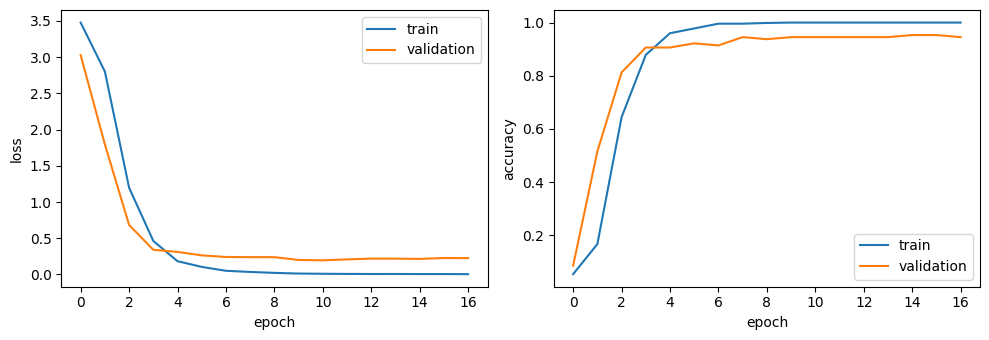

In [8]:
if HAS_KERAS:
    keras.utils.set_random_seed(RS)
    model, attn_model = build_model()
    t0 = time.time()
    hist = model.fit(X_tr, y_tr, validation_split=0.15, epochs=60, batch_size=32, verbose=0,
                     callbacks=[keras.callbacks.EarlyStopping(
                         monitor="val_loss", patience=6, restore_best_weights=True)])
    print(f"trained {len(hist.history['loss'])} epochs in {time.time() - t0:.1f} s")
    print("parameters:", model.count_params())

    fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
    ax[0].plot(hist.history["loss"], label="train"); ax[0].plot(hist.history["val_loss"], label="validation")
    ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].legend()
    ax[1].plot(hist.history["accuracy"], label="train"); ax[1].plot(hist.history["val_accuracy"], label="validation")
    ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy"); ax[1].legend()
    plt.tight_layout(); plt.show()
else:
    hist = None
    print("Skipped (no Keras).")

## 6. 測試集：和 TF-IDF 基準比較
測試集只有 212 筆，答錯一題準確率就差 0.5 個百分點。所以除了準確率，我們用**自助法（bootstrap）**重抽測試集 2,000 次，估計兩個模型準確率差距的 95% 信賴區間。

In [9]:
if hist is not None:
    proba_tf = model.predict(X_te, verbose=0)
    pred_tf = np.array(classes)[proba_tf.argmax(axis=1)]
    acc_tf = np.mean(pred_tf == y_test_text.to_numpy())
    print(f"TF-IDF + LR       test accuracy: {acc_base:.3f}")
    print(f"mini Transformer  test accuracy: {acc_tf:.3f}")

    correct_base = (pred_base == y_test_text.to_numpy()).astype(float)
    correct_tf = (pred_tf == y_test_text.to_numpy()).astype(float)
    rng = np.random.default_rng(RS)
    idx = rng.integers(0, len(correct_tf), size=(2000, len(correct_tf)))
    diff = correct_tf[idx].mean(axis=1) - correct_base[idx].mean(axis=1)
    lo, hi = np.percentile(diff, [2.5, 97.5])
    print(f"difference (Transformer - TF-IDF): {acc_tf - acc_base:+.3f}, bootstrap 95% CI [{lo:+.3f}, {hi:+.3f}]")
    print("both wrong on", int(((correct_base == 0) & (correct_tf == 0)).sum()), "test descriptions")
else:
    print("Skipped (no Keras).")

TF-IDF + LR       test accuracy: 0.906
mini Transformer  test accuracy: 0.929
difference (Transformer - TF-IDF): +0.024, bootstrap 95% CI [-0.009, +0.061]
both wrong on 10 test descriptions


如果信賴區間跨過 0，代表這份測試集**不足以判斷哪個模型比較好**。在小資料上，簡單的 TF-IDF 常常就夠用；Transformer 的優勢要在大量資料、或先在大量文字上預訓練之後才會顯現。

## 7. 打開黑盒子：注意力權重
`attn_model` 輸出的形狀是 `(句子數, 頭數, 查詢位置, 被看的位置)`。我們看一則測試句：

- 上圖：每個注意力頭裡，`[CLS]` 把注意力分給哪些字（每一列加總為 1）。
- 下圖：第 1 個頭的完整注意力矩陣——每一列是一個字「去看」其他字的權重。

text      : I've been feeling really sick. I have a fever, chills, nausea, and a headache. I've also been sweating a lot and my muscles ache.
true label: malaria | predicted: malaria (1.00)
uniform attention would be 1/25 = 0.040


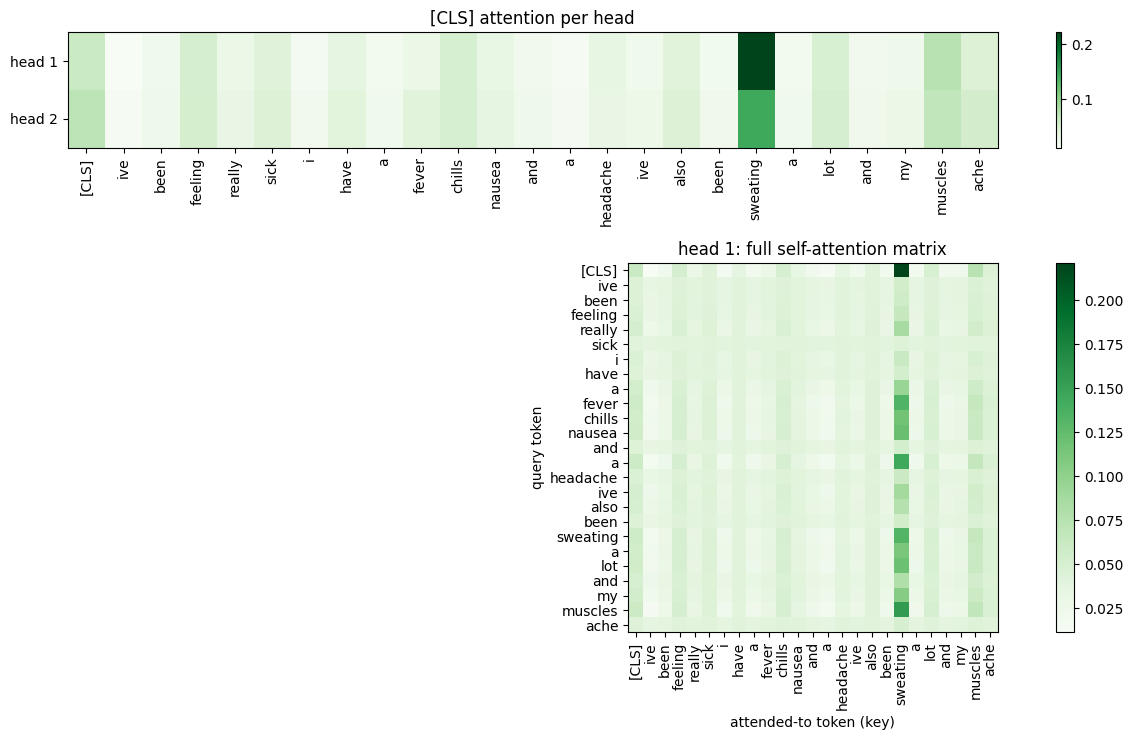

In [10]:
def show_attention(i):
    n = int((X_te[i] != 0).sum())
    tokens = [vocab[t] for t in X_te[i, :n]]
    scores = attn_model.predict(X_te[i:i + 1], verbose=0)[0][:, :n, :n]   # (heads, n, n)
    p = model.predict(X_te[i:i + 1], verbose=0)[0]
    print("text      :", test_df.loc[i, "input_text"])
    print("true label:", y_test_text[i], "| predicted:", classes[p.argmax()], f"({p.max():.2f})")
    print(f"uniform attention would be 1/{n} = {1 / n:.3f}")

    fig, ax = plt.subplots(2, 1, figsize=(min(0.42 * n + 2, 16), 7.5),
                           gridspec_kw={"height_ratios": [1, 3.2]})
    im0 = ax[0].imshow(scores[:, 0, :], cmap="Greens", aspect="auto")
    ax[0].set_yticks(range(scores.shape[0]), [f"head {h + 1}" for h in range(scores.shape[0])])
    ax[0].set_xticks(range(n), tokens, rotation=90)
    ax[0].set_title("[CLS] attention per head")
    fig.colorbar(im0, ax=ax[0])
    im1 = ax[1].imshow(scores[0], cmap="Greens")
    ax[1].set_xticks(range(n), tokens, rotation=90)
    ax[1].set_yticks(range(n), tokens)
    ax[1].set_xlabel("attended-to token (key)"); ax[1].set_ylabel("query token")
    ax[1].set_title("head 1: full self-attention matrix")
    fig.colorbar(im1, ax=ax[1])
    plt.tight_layout(); plt.show()

if hist is not None:
    show_attention(12)
else:
    print("Skipped (no Keras).")

權重大致**只比平均分配高一點**：小資料、只有一層的模型，注意力不會像教科書插圖那樣集中在一兩個字。即使如此，`[CLS]` 通常還是會多看幾眼帶有診斷線索的字（例如 sweating、chills）。

要記得：注意力權重**不等於**模型「為什麼這樣判斷」的完整解釋。後面還有前饋網路與分類頭，權重高只代表那個字的資訊被多混進來一些。換成第 55 句（`show_attention(55)`）或其他句子看看。

## 8. 錯誤分析：哪些診斷最常被搞混？
把兩個模型答錯的題目依「真實診斷 → 預測診斷」數一數。

In [11]:
def confused_pairs(pred, top=6):
    wrong = pd.DataFrame({"true": y_test_text.to_numpy(), "pred": pred})
    wrong = wrong[wrong["true"] != wrong["pred"]]
    return wrong.value_counts().head(top)

print("TF-IDF + LR errors:", int((pred_base != y_test_text).sum()))
print(confused_pairs(pred_base))
if hist is not None:
    print("\nmini Transformer errors:", int((pred_tf != y_test_text.to_numpy()).sum()))
    print(confused_pairs(pred_tf))

TF-IDF + LR errors: 20
true                  pred                           
peptic ulcer disease  gastroesophageal reflux disease    3
dengue                typhoid                            2
allergy               common cold                        1
jaundice              urinary tract infection            1
typhoid               dengue                             1
pneumonia             bronchial asthma                   1
Name: count, dtype: int64

mini Transformer errors: 15
true                             pred                   
dengue                           malaria                    1
                                 typhoid                    1
diabetes                         pneumonia                  1
                                 urinary tract infection    1
gastroesophageal reflux disease  allergy                    1
                                 peptic ulcer disease       1
Name: count, dtype: int64


錯誤常落在臨床上本來就需要鑑別的組合，例如發燒類的感染症、或同樣以消化道症狀表現的疾病。光靠一句主訴分不出來是合理的——真實診斷還需要病史、理學檢查與檢驗。

## 9. 用自己寫的句子試試
輸入一段英文症狀描述，看兩個模型的前三名預測。注意：這是教學模型，對訓練資料以外的寫法很容易出錯。

In [12]:
my_text = "I have had a high fever with chills and sweating every other day, and my muscles ache."

top3_base = pd.Series(baseline.predict_proba([my_text])[0], index=baseline.classes_).nlargest(3)
print("TF-IDF + LR top-3:"); print(top3_base.round(3))
if hist is not None:
    p = model.predict(encode([my_text]), verbose=0)[0]
    print("\nmini Transformer top-3:"); print(pd.Series(p, index=classes).nlargest(3).round(3))

TF-IDF + LR top-3:
malaria    0.185
dengue     0.070
typhoid    0.052
dtype: float64



mini Transformer top-3:
malaria      0.906
pneumonia    0.076
impetigo     0.006
dtype: float32


softmax 輸出的「0.9」只代表模型在這 22 類裡的相對偏好，不是校準過的機率；就算你輸入一句和 22 類都無關的話，它也一定會選出一個答案。

## 10. 動手試試
1. 在第 5 節把 `build_model()` 改成 `build_model(num_heads=4)` 或 `build_model(dim=32)`，準確率與注意力圖怎麼變？
2. 改成 `build_model(use_position=False)`（拿掉位置嵌入，模型就看不到字序），準確率掉多少？想想為什麼在這份資料上可能差不多。
3. 把第 6 節 bootstrap 的次數改成 500 或 5,000，信賴區間穩不穩定？再把 `keras.utils.set_random_seed` 的種子換成 1、7，看看「同一個模型、只換隨機種子」準確率會跳動多少——和兩個模型的差距相比如何？